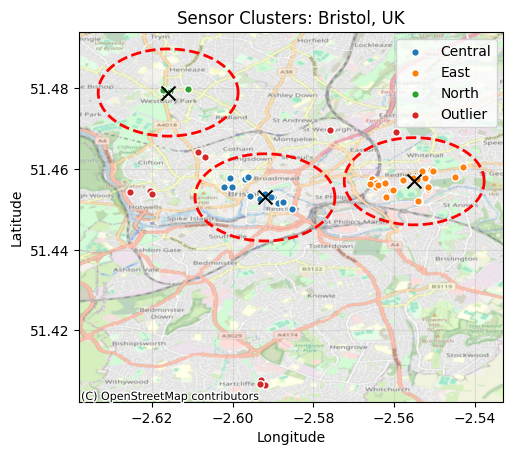

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx # this is the file that handles integrating a map with plt
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
RAW_DATA_DIR = NOTEBOOK_DIR / 'Raw Data'
PROCESSED_DATA_DIR = NOTEBOOK_DIR / 'Processed Data'

df = pd.read_csv(RAW_DATA_DIR / 'Sensor_Location.csv')

centres = {
    "Central": (-2.592, 51.453), #2
    "East": (-2.555, 51.457), #42
    "North": (-2.616, 51.479) #63
}

mean_lat = df["Latitude"].mean()

lat_to_m = 111000
lon_to_m = 111000 * np.cos(np.deg2rad(mean_lat))

def distance_m(lon1, lat1, lon2, lat2):
    dx = (lon1 - lon2) * lon_to_m
    dy = (lat1 - lat2) * lat_to_m
    return np.sqrt(dx**2 + dy**2)

radius = 1200 

cluster_labels = []

for _, row in df.iterrows():
    distances = {
        name: distance_m(row["Longitude"], row["Latitude"], clon, clat)
        for name, (clon, clat) in centres.items()
    }
    
    closest_cluster = min(distances, key=distances.get)
    
    if distances[closest_cluster] <= radius:
        cluster_labels.append(closest_cluster)
    else:
        cluster_labels.append("Outlier")

df["Cluster"] = cluster_labels

# --- This is a small change to the original that turns the output to a grid plotted on a real map with contextily

for name, group in df.groupby("Cluster"):
    # I've put a white boarder around each marker
    plt.scatter(group["Longitude"], group["Latitude"], label=name, s=30, edgecolors='white', zorder=3)

theta = np.linspace(0, 2*np.pi, 200)

for name, (clon, clat) in centres.items():
    circle_lon = clon + (radius / lon_to_m) * np.cos(theta)
    circle_lat = clat + (radius / lat_to_m) * np.sin(theta)
    
    # I've inclued a small black marker in each sector
    plt.plot(circle_lon, circle_lat, color = 'red', linestyle = '--', linewidth = 2, zorder = 4)
    plt.scatter(clon, clat, marker = "x", color = 'black', s = 100, zorder = 5) 

# This fetches map tiles from openstreetmap
# crs="EPSG:4326" is just the code for the lat/long convention
# alpha is teh "translucentness" of the map
ctx.add_basemap(plt.gca(), crs = "EPSG:4326", source = ctx.providers.OpenStreetMap.Mapnik, alpha =0.8)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Sensor Clusters: Bristol, UK")
plt.legend()
plt.grid(True, alpha=0.3) # Dimmed grid lines so they don't ruin the map
plt.gca().set_aspect("equal", adjustable="box")
plt.show()


In [25]:
from pathlib import Path

raw_data_dir = RAW_DATA_DIR if 'RAW_DATA_DIR' in globals() else Path.cwd() / 'Raw Data'
processed_data_dir = PROCESSED_DATA_DIR if 'PROCESSED_DATA_DIR' in globals() else Path.cwd() / 'Processed Data'
location_path = raw_data_dir / 'Sensor_Location.csv'
output_path = processed_data_dir / 'all_sensor_data_with_locations_and_clusters.csv'

# Build one big sensor table with location + cluster data
location_with_clusters = pd.read_csv(location_path).copy()

mean_lat = location_with_clusters['Latitude'].mean()
lat_to_m = 111000
lon_to_m = 111000 * np.cos(np.deg2rad(mean_lat))

def distance_m(lon1, lat1, lon2, lat2):
    dx = (lon1 - lon2) * lon_to_m
    dy = (lat1 - lat2) * lat_to_m
    return np.sqrt(dx**2 + dy**2)

cluster_labels = []

for _, row in location_with_clusters.iterrows():
    distances = {
        name: distance_m(row['Longitude'], row['Latitude'], clon, clat)
        for name, (clon, clat) in centres.items()
    }

    closest_cluster = min(distances, key=distances.get)

    if distances[closest_cluster] <= radius:
        cluster_labels.append(closest_cluster)
    else:
        cluster_labels.append('Outlier')

location_with_clusters['Cluster'] = cluster_labels
cluster_number_map = {'Central': 1, 'East': 2, 'North': 3, 'Outlier': 0}
location_with_clusters['ClusterNumber'] = location_with_clusters['Cluster'].map(cluster_number_map)

sensor_files = sorted(
    [path for path in raw_data_dir.glob('*.csv') if path.name != 'Sensor_Location.csv' and path.stem.isdigit()],
    key=lambda path: int(path.stem)
)

sensor_frames = []
for sensor_file in sensor_files:
    sensor_df = pd.read_csv(sensor_file).copy()
    sensor_df.columns = [col.strip() for col in sensor_df.columns]
    sensor_df['SensorNumber'] = int(sensor_file.stem)
    sensor_frames.append(sensor_df)

big_sensor_table = pd.concat(sensor_frames, ignore_index=True, sort=False)
big_sensor_table['date'] = pd.to_datetime(big_sensor_table['date'], errors='coerce')

big_sensor_table = big_sensor_table.merge(
    location_with_clusters[['SensorNumber', 'ClusterNumber', 'Cluster', 'Longitude', 'Latitude']],
    on='SensorNumber',
    how='left'
)

column_order = [
    'SensorNumber', 'ClusterNumber', 'Cluster', 'Longitude', 'Latitude', 'date', 'ped', 'car', 'cyc'
]
big_sensor_table = big_sensor_table[column_order].sort_values(['SensorNumber', 'date']).reset_index(drop=True)
big_sensor_table.to_csv(output_path, index=False)

print(f'Combined {len(sensor_files)} sensor files into {len(big_sensor_table):,} rows.')
print(f'Output saved to: {output_path}')
big_sensor_table.head()


Combined 58 sensor files into 509,472 rows.
Output saved to: /Users/karandama/Documents/School stuff/Uni Shit/Y2/MDM2/Group-3-MDM/Karan - Notebooks and analysis/Processed Data/all_sensor_data_with_locations_and_clusters.csv


,SensorNumber,ClusterNumber,Cluster,Longitude,Latitude,date,ped,car,cyc
0,1,1,Central,-2.591538,51.453815,2024-01-01 00:00:00,413,381,9
1,1,1,Central,-2.591538,51.453815,2024-01-01 01:00:00,402,489,10
2,1,1,Central,-2.591538,51.453815,2024-01-01 02:00:00,421,473,10
3,1,1,Central,-2.591538,51.453815,2024-01-01 03:00:00,370,419,4
4,1,1,Central,-2.591538,51.453815,2024-01-01 04:00:00,132,123,2


In [26]:
MIN_ZERO_STREAK_DAYS= 7

# A zero day means the full daily sum of ped + car + cyc is exactly 0.
if 'output_path' not in globals():
    output_path = (PROCESSED_DATA_DIR if 'PROCESSED_DATA_DIR' in globals() else Path.cwd() / 'Processed Data') / 'all_sensor_data_with_locations_and_clusters.csv'

if 'big_sensor_table' in globals():
    zero_check_df = big_sensor_table.copy()
else:
    zero_check_df = pd.read_csv(output_path)

zero_check_df['date'] = pd.to_datetime(zero_check_df['date'], errors='coerce')
zero_check_df['day'] = zero_check_df['date'].dt.normalize()
zero_check_df['total_count'] = zero_check_df[['ped', 'car', 'cyc']].fillna(0).sum(axis=1)

daily_totals = (
    zero_check_df.groupby(['SensorNumber', 'Cluster', 'day'], as_index=False)
    .agg(total_count=('total_count', 'sum'))
)
daily_totals['is_zero_day'] = daily_totals['total_count'].eq(0)

streak_rows = []

for sensor_id, sensor_daily in daily_totals.groupby('SensorNumber', sort=True):
    sensor_daily = sensor_daily.sort_values('day').copy()
    sensor_daily['new_streak'] = (
        (~sensor_daily['is_zero_day'])
        | sensor_daily['day'].diff().dt.days.ne(1)
    )
    sensor_daily['streak_group'] = sensor_daily['new_streak'].cumsum()

    zero_days_only = sensor_daily[sensor_daily['is_zero_day']].copy()
    if zero_days_only.empty:
        continue

    sensor_streaks = (
        zero_days_only.groupby('streak_group', as_index=False)
        .agg(
            SensorNumber=('SensorNumber', 'first'),
            Cluster=('Cluster', 'first'),
            start_day=('day', 'min'),
            end_day=('day', 'max'),
            zero_days=('day', 'size')
        )[['SensorNumber', 'Cluster', 'start_day', 'end_day', 'zero_days']]
    )
    streak_rows.append(sensor_streaks)

if streak_rows:
    zero_day_streaks = pd.concat(streak_rows, ignore_index=True)
else:
    zero_day_streaks = pd.DataFrame(
        columns=['SensorNumber', 'Cluster', 'start_day', 'end_day', 'zero_days']
    )

zero_day_streaks = zero_day_streaks[zero_day_streaks['zero_days'] >= MIN_ZERO_STREAK_DAYS]
zero_day_streaks = zero_day_streaks.sort_values(
    ['zero_days', 'SensorNumber', 'start_day'],
    ascending=[False, True, True]
).reset_index(drop=True)

if zero_day_streaks.empty:
    print(f'No sensors have {MIN_ZERO_STREAK_DAYS}+ consecutive zero-count days.')
else:
    sensors_with_zero_runs = sorted(zero_day_streaks['SensorNumber'].unique().tolist())
    print(f'Sensors with {MIN_ZERO_STREAK_DAYS}+ consecutive zero-count days: {sensors_with_zero_runs}')
    print(f'Total sensors flagged: {len(sensors_with_zero_runs)}')
    zero_day_streaks


Sensors with 7+ consecutive zero-count days: [6, 12, 24, 27, 30, 34, 36, 37, 38, 48, 49, 50, 51, 54, 56, 61, 62, 63, 64, 67, 105]
Total sensors flagged: 21


Removed 21 sensors with 7+ consecutive zero-count days.
Sensors remaining on map: 37


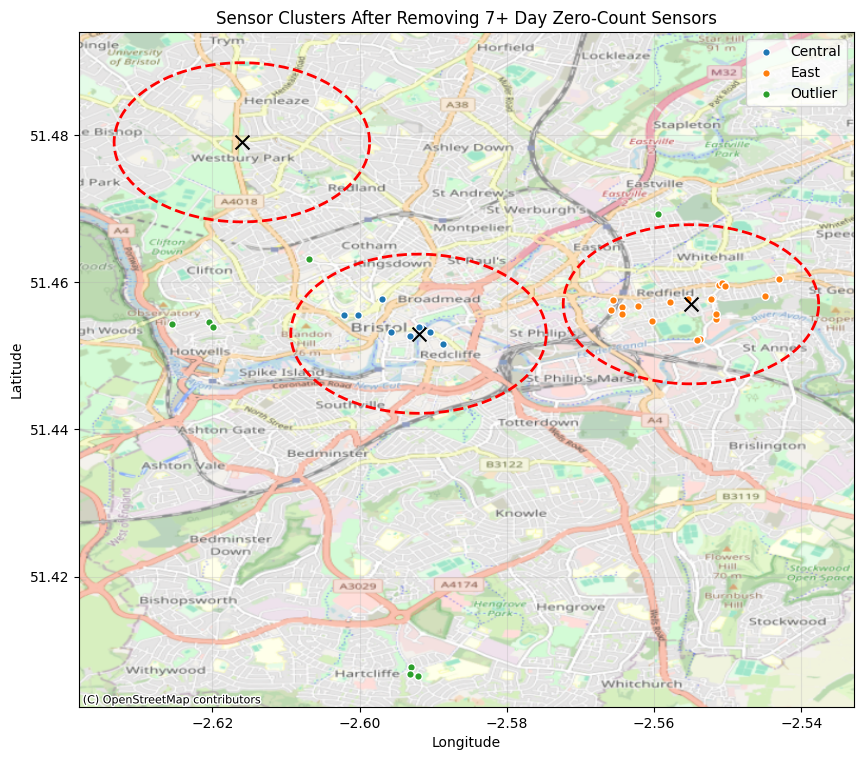

Updated merged table saved to: /Users/karandama/Documents/School stuff/Uni Shit/Y2/MDM2/Group-3-MDM/Karan - Notebooks and analysis/Processed Data/all_sensor_data_with_locations_and_clusters.csv
Rows: 509,472 -> 325,008
Sensors: 58 -> 37


In [27]:
if 'sensors_with_zero_runs' not in globals():
    if 'zero_day_streaks' not in globals():
        raise ValueError('Run the zero-streak cell first so zero_day_streaks is available.')
    sensors_with_zero_runs = sorted(
        zero_day_streaks.loc[zero_day_streaks['zero_days'] >= MIN_ZERO_STREAK_DAYS, 'SensorNumber']
        .unique()
        .tolist()
    )

if 'df' not in globals() or 'Cluster' not in df.columns:
    df = pd.read_csv((RAW_DATA_DIR if 'RAW_DATA_DIR' in globals() else Path.cwd() / 'Raw Data') / 'Sensor_Location.csv')
    cluster_labels = []
    for _, row in df.iterrows():
        distances = {
            name: distance_m(row['Longitude'], row['Latitude'], clon, clat)
            for name, (clon, clat) in centres.items()
        }
        closest_cluster = min(distances, key=distances.get)
        if distances[closest_cluster] <= radius:
            cluster_labels.append(closest_cluster)
        else:
            cluster_labels.append('Outlier')
    df['Cluster'] = cluster_labels

filtered_map_df = df[~df['SensorNumber'].isin(sensors_with_zero_runs)].copy()

print(f'Removed {len(sensors_with_zero_runs)} sensors with {MIN_ZERO_STREAK_DAYS}+ consecutive zero-count days.')
print(f'Sensors remaining on map: {len(filtered_map_df)}')

plt.figure(figsize=(10, 10))

for name, group in filtered_map_df.groupby('Cluster'):
    plt.scatter(group['Longitude'], group['Latitude'], label=name, s=30, edgecolors='white', zorder=3)

theta = np.linspace(0, 2*np.pi, 200)

for name, (clon, clat) in centres.items():
    circle_lon = clon + (radius / lon_to_m) * np.cos(theta)
    circle_lat = clat + (radius / lat_to_m) * np.sin(theta)
    plt.plot(circle_lon, circle_lat, color='red', linestyle='--', linewidth=2, zorder=4)
    plt.scatter(clon, clat, marker='x', color='black', s=100, zorder=5)

ctx.add_basemap(plt.gca(), crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.8)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Sensor Clusters After Removing {MIN_ZERO_STREAK_DAYS}+ Day Zero-Count Sensors')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

if 'output_path' not in globals():
    output_path = (PROCESSED_DATA_DIR if 'PROCESSED_DATA_DIR' in globals() else Path.cwd() / 'Processed Data') / 'all_sensor_data_with_locations_and_clusters.csv'

if output_path.exists():
    filtered_table = pd.read_csv(output_path)
elif 'big_sensor_table' in globals():
    filtered_table = big_sensor_table.copy()
else:
    raise ValueError('Run the merged-table cell first so there is a table to filter.')

rows_before = len(filtered_table)
sensors_before = filtered_table['SensorNumber'].nunique()
filtered_table = filtered_table[~filtered_table['SensorNumber'].isin(sensors_with_zero_runs)].copy()
rows_after = len(filtered_table)
sensors_after = filtered_table['SensorNumber'].nunique()

filtered_table.to_csv(output_path, index=False)
big_sensor_table = filtered_table.copy()

print(f'Updated merged table saved to: {output_path}')
print(f'Rows: {rows_before:,} -> {rows_after:,}')
print(f'Sensors: {sensors_before} -> {sensors_after}')


In [28]:
def solar_altitude_deg(dt_utc, lat_deg, lon_deg):
    dts = pd.to_datetime(dt_utc, utc=True)
    n = dts.dt.dayofyear.to_numpy()
    hour = (dts.dt.hour + dts.dt.minute/60.0 + dts.dt.second/3600.0).to_numpy()
    lat = np.deg2rad(lat_deg)
    gamma = 2.0*np.pi/365.0 * (n - 1 + (hour - 12)/24.0)

    decl = (0.006918
            - 0.399912*np.cos(gamma) + 0.070257*np.sin(gamma)
            - 0.006758*np.cos(2*gamma) + 0.000907*np.sin(2*gamma)
            - 0.002697*np.cos(3*gamma) + 0.00148*np.sin(3*gamma))

    eqtime = 229.18*(0.000075
                     + 0.001868*np.cos(gamma) - 0.032077*np.sin(gamma)
                     - 0.014615*np.cos(2*gamma) - 0.040849*np.sin(2*gamma))

    tst = (hour*60.0 + eqtime + 4.0*lon_deg) % 1440.0
    ha = np.deg2rad((tst/4.0) - 180.0)

    cos_zen = np.sin(lat)*np.sin(decl) + np.cos(lat)*np.cos(decl)*np.cos(ha)
    cos_zen = np.clip(cos_zen, -1.0, 1.0)

    zen = np.arccos(cos_zen)
    alt = np.rad2deg(np.pi/2 - zen)
    return alt

In [29]:
if 'output_path' not in globals():
    output_path = (PROCESSED_DATA_DIR if 'PROCESSED_DATA_DIR' in globals() else Path.cwd() / 'Processed Data') / 'all_sensor_data_with_locations_and_clusters.csv'

if 'big_sensor_table' in globals():
    light_table = big_sensor_table.copy()
else:
    light_table = pd.read_csv(output_path)

light_table['date'] = pd.to_datetime(light_table['date'], errors='coerce')
light_table['solar_altitude_deg'] = np.nan

for sensor_id, sensor_rows in light_table.groupby('SensorNumber', sort=False):
    lat = float(sensor_rows['Latitude'].iloc[0])
    lon = float(sensor_rows['Longitude'].iloc[0])
    light_table.loc[sensor_rows.index, 'solar_altitude_deg'] = solar_altitude_deg(sensor_rows['date'], lat, lon)

alt = light_table['solar_altitude_deg']
light_table['light_class'] = np.where(
    alt > 0,
    'daylight',
    np.where(alt < -6, 'darkness', 'twilight')
)
light_table['Dark'] = (light_table['light_class'] == 'darkness').astype(int)

preferred_order = [
    'SensorNumber', 'ClusterNumber', 'Cluster', 'Longitude', 'Latitude', 'date',
    'ped', 'car', 'cyc', 'solar_altitude_deg', 'light_class', 'Dark'
]
remaining_columns = [col for col in light_table.columns if col not in preferred_order]
light_table = light_table[preferred_order + remaining_columns]

light_table.to_csv(output_path, index=False)
big_sensor_table = light_table.copy()

print(f'Updated merged table saved to: {output_path}')
print(light_table['light_class'].value_counts(dropna=False))
light_table[['SensorNumber', 'date', 'solar_altitude_deg', 'light_class', 'Dark']].head()


Updated merged table saved to: /Users/karandama/Documents/School stuff/Uni Shit/Y2/MDM2/Group-3-MDM/Karan - Notebooks and analysis/Processed Data/all_sensor_data_with_locations_and_clusters.csv
light_class
daylight    162830
darkness    142400
twilight     19778
Name: count, dtype: int64


,SensorNumber,date,solar_altitude_deg,light_class,Dark
0,1,2024-01-01 00:00:00,-61.529806,darkness,1
1,1,2024-01-01 01:00:00,-60.225898,darkness,1
2,1,2024-01-01 02:00:00,-54.953852,darkness,1
3,1,2024-01-01 03:00:00,-47.266506,darkness,1
4,1,2024-01-01 04:00:00,-38.404055,darkness,1


In [30]:
from IPython.display import display

if 'output_path' not in globals():
    output_path = (PROCESSED_DATA_DIR if 'PROCESSED_DATA_DIR' in globals() else Path.cwd() / 'Processed Data') / 'all_sensor_data_with_locations_and_clusters.csv'

or_df = pd.read_csv(output_path, parse_dates=['date'])
or_df['day'] = or_df['date'].dt.normalize()
or_df['hour'] = or_df['date'].dt.hour.astype(int)

hour_mix = or_df.groupby('hour')['Dark'].agg(['min', 'max', 'mean']).sort_index()
selected_case_hours = [5, 6, 17, 18, 19, 20]
dark_control_hours = [23, 0, 1, 2]
daylight_control_hours = [9, 10, 11, 12, 13, 14]
control_row_specs = [('Dark', hour_value) for hour_value in dark_control_hours] + [('Daylight', hour_value) for hour_value in daylight_control_hours]

for case_hour in selected_case_hours:
    if case_hour not in hour_mix.index or not (hour_mix.loc[case_hour, 'min'] == 0 and hour_mix.loc[case_hour, 'max'] == 1):
        raise ValueError(f'Case hour {case_hour:02d}:00 is not a mixed light/dark hour in the current data.')

for control_hour in dark_control_hours:
    if control_hour not in hour_mix.index or not (hour_mix.loc[control_hour, 'min'] == 1 and hour_mix.loc[control_hour, 'max'] == 1):
        raise ValueError(f'Control hour {control_hour:02d}:00 is not always dark in the current data.')

for control_hour in daylight_control_hours:
    if control_hour not in hour_mix.index or not (hour_mix.loc[control_hour, 'min'] == 0 and hour_mix.loc[control_hour, 'max'] == 0):
        raise ValueError(f'Control hour {control_hour:02d}:00 is not always daylight in the current data.')

def hour_label(hour_value):
    return f'{int(hour_value):02d}:00-{int(hour_value):02d}:59'

# A, B, C, D follow the exact case-control definition you gave.
def compute_case_control_or(cluster_df, outcome, case_h, ctrl_h):
    case_rows = cluster_df.loc[
        cluster_df['hour'] == case_h,
        ['SensorNumber', 'day', 'Dark', outcome]
    ].rename(columns={outcome: 'case_count'})

    ctrl_rows = cluster_df.loc[
        cluster_df['hour'] == ctrl_h,
        ['SensorNumber', 'day', outcome]
    ].rename(columns={outcome: 'control_count'})

    paired = case_rows.merge(ctrl_rows, on=['SensorNumber', 'day'], how='inner')

    A = paired.loc[paired['Dark'] == 0, 'case_count'].sum()
    B = paired.loc[paired['Dark'] == 1, 'case_count'].sum()
    C = paired.loc[paired['Dark'] == 0, 'control_count'].sum()
    D = paired.loc[paired['Dark'] == 1, 'control_count'].sum()

    eps = 1e-9
    R_odds = ((A + eps) / (B + eps)) / ((C + eps) / (D + eps))

    return {
        'A': A,
        'B': B,
        'C': C,
        'D': D,
        'R_odds': R_odds,
        'paired_rows': len(paired),
    }

cluster_order = [cluster for cluster in ['Central', 'East', 'North', 'Outlier'] if cluster in or_df['Cluster'].dropna().unique()]
mode_map = {
    'ped': 'Pedestrians',
    'car': 'Cars',
    'cyc': 'Cyclists',
}

print('Selected case hours:', [hour_label(hour_value) for hour_value in selected_case_hours])
print('Dark control hours:', [hour_label(hour_value) for hour_value in dark_control_hours])
print('Daylight control hours:', [hour_label(hour_value) for hour_value in daylight_control_hours])
print('Clusters included:', cluster_order)
print('Case-hour dark fractions:')
print(hour_mix.loc[selected_case_hours, ['mean']].rename(columns={'mean': 'dark_fraction'}))

case_control_or_tables = {}
case_control_or_long = []

for cluster_name in cluster_order:
    cluster_df = or_df[or_df['Cluster'] == cluster_name].copy()

    for mode_column, mode_name in mode_map.items():
        table = pd.DataFrame(
            index=pd.MultiIndex.from_tuples(
                [(control_type, hour_label(hour_value)) for control_type, hour_value in control_row_specs],
                names=['Control hours', '']
            ),
            columns=pd.MultiIndex.from_product(
                [['Case hours'], [hour_label(hour_value) for hour_value in selected_case_hours]]
            ),
            dtype=float,
        )

        for control_type, ctrl_h in control_row_specs:
            for case_h in selected_case_hours:
                result = compute_case_control_or(cluster_df, mode_column, case_h, ctrl_h)
                table.loc[(control_type, hour_label(ctrl_h)), ('Case hours', hour_label(case_h))] = result['R_odds']

                case_control_or_long.append({
                    'Cluster': cluster_name,
                    'Mode': mode_name,
                    'control_type': control_type,
                    'control_hour': int(ctrl_h),
                    'control_hour_label': hour_label(ctrl_h),
                    'case_hour': int(case_h),
                    'case_hour_label': hour_label(case_h),
                    **result,
                })

        case_control_or_tables[(cluster_name, mode_name)] = table.round(2)

case_control_or_long = pd.DataFrame(case_control_or_long)
case_control_or_path = output_path.parent / 'case_control_hour_or_by_cluster_mode_long.csv'
case_control_or_long.to_csv(case_control_or_path, index=False)

for (cluster_name, mode_name), table in case_control_or_tables.items():
    print('\n' + '=' * 80)
    print(f'{cluster_name} | {mode_name}')
    display(table.style.format('{:.2f}'))

print(f'\nSaved long-form OR results to: {case_control_or_path}')


Selected case hours: ['05:00-05:59', '06:00-06:59', '17:00-17:59', '18:00-18:59', '19:00-19:59', '20:00-20:59']
Dark control hours: ['23:00-23:59', '00:00-00:59', '01:00-01:59', '02:00-02:59']
Daylight control hours: ['09:00-09:59', '10:00-10:59', '11:00-11:59', '12:00-12:59', '13:00-13:59', '14:00-14:59']
Clusters included: ['Central', 'East', 'Outlier']
Case-hour dark fractions:
      dark_fraction
hour               
5          0.576503
6          0.404593
17         0.155738
18         0.351278
19         0.516393
20         0.680328

Central | Pedestrians



Central | Cars



Central | Cyclists



East | Pedestrians



East | Cars



East | Cyclists



Outlier | Pedestrians



Outlier | Cars



Outlier | Cyclists



Saved long-form OR results to: /Users/karandama/Documents/School stuff/Uni Shit/Y2/MDM2/Group-3-MDM/Karan - Notebooks and analysis/Processed Data/case_control_hour_or_by_cluster_mode_long.csv


In [ ]:
from IPython.display import display

if 'output_path' not in globals():
    output_path = (PROCESSED_DATA_DIR if 'PROCESSED_DATA_DIR' in globals() else Path.cwd() / 'Processed Data') / 'all_sensor_data_with_locations_and_clusters.csv'

if 'or_df' not in globals():
    or_df = pd.read_csv(output_path, parse_dates=['date'])
    or_df['day'] = or_df['date'].dt.normalize()
    or_df['hour'] = or_df['date'].dt.hour.astype(int)

if 'selected_case_hours' not in globals():
    selected_case_hours = [5, 6, 17, 18, 19, 20]

if 'dark_control_hours' not in globals():
    dark_control_hours = [23, 0, 1, 2]

if 'daylight_control_hours' not in globals():
    daylight_control_hours = [9, 10, 11, 12, 13, 14]

if 'control_row_specs' not in globals():
    control_row_specs = [('Dark', hour_value) for hour_value in dark_control_hours] + [('Daylight', hour_value) for hour_value in daylight_control_hours]

if 'hour_label' not in globals():
    def hour_label(hour_value):
        return f'{int(hour_value):02d}:00-{int(hour_value):02d}:59'

if 'compute_case_control_or' not in globals():
    def compute_case_control_or(cluster_df, outcome, case_h, ctrl_h):
        case_rows = cluster_df.loc[
            cluster_df['hour'] == case_h,
            ['SensorNumber', 'day', 'Dark', outcome]
        ].rename(columns={outcome: 'case_count'})

        ctrl_rows = cluster_df.loc[
            cluster_df['hour'] == ctrl_h,
            ['SensorNumber', 'day', outcome]
        ].rename(columns={outcome: 'control_count'})

        paired = case_rows.merge(ctrl_rows, on=['SensorNumber', 'day'], how='inner')

        A = paired.loc[paired['Dark'] == 0, 'case_count'].sum()
        B = paired.loc[paired['Dark'] == 1, 'case_count'].sum()
        C = paired.loc[paired['Dark'] == 0, 'control_count'].sum()
        D = paired.loc[paired['Dark'] == 1, 'control_count'].sum()

        eps = 1e-9
        R_odds = ((A + eps) / (B + eps)) / ((C + eps) / (D + eps))

        return {
            'A': A,
            'B': B,
            'C': C,
            'D': D,
            'R_odds': R_odds,
            'paired_rows': len(paired),
        }

pooled_mode_map = {
    'ped': 'Pedestrians',
    'cyc': 'Cyclists',
}

pooled_case_control_tables = {}
pooled_case_control_long = []

print('Pooled case-control OR tables across all cleaned sensors (no cluster split).')
print('Sensors included:', or_df['SensorNumber'].nunique())

for mode_column, mode_name in pooled_mode_map.items():
    table = pd.DataFrame(
        index=pd.MultiIndex.from_tuples(
            [(control_type, hour_label(hour_value)) for control_type, hour_value in control_row_specs],
            names=['Control hours', '']
        ),
        columns=pd.MultiIndex.from_product(
            [['Case hours'], [hour_label(hour_value) for hour_value in selected_case_hours]]
        ),
        dtype=float,
    )

    for control_type, ctrl_h in control_row_specs:
        for case_h in selected_case_hours:
            result = compute_case_control_or(or_df, mode_column, case_h, ctrl_h)
            table.loc[(control_type, hour_label(ctrl_h)), ('Case hours', hour_label(case_h))] = result['R_odds']

            pooled_case_control_long.append({
                'Mode': mode_name,
                'control_type': control_type,
                'control_hour': int(ctrl_h),
                'control_hour_label': hour_label(ctrl_h),
                'case_hour': int(case_h),
                'case_hour_label': hour_label(case_h),
                **result,
            })

    pooled_case_control_tables[mode_name] = table.round(2)

pooled_case_control_long = pd.DataFrame(pooled_case_control_long)
pooled_case_control_path = output_path.parent / 'case_control_hour_or_pooled_ped_cyc_long.csv'
pooled_case_control_long.to_csv(pooled_case_control_path, index=False)

for mode_name, table in pooled_case_control_tables.items():
    print('\n' + '=' * 80)
    print(f'All cleaned sensors | {mode_name}')
    display(table.style.format('{:.2f}'))

print(f'\nSaved pooled long-form OR results to: {pooled_case_control_path}')


## Paper-style weighted Mantel-Haenszel OR across the hour matrix

This section now mirrors the approach used in Fotios et al. (2024, PLOS One). The key idea is that we treat each **case-hour / control-hour combination** as one stratum in a weighted pooled odds ratio.

For each mode, we first calculate the 2x2 table for every valid hour pairing:

- `A` = count in the case hour when that case hour is in daylight
- `B` = count in the case hour when that case hour is in darkness
- `C` = count in the control hour during the daylight-case periods
- `D` = count in the control hour during the dark-case periods

The pooled weighted odds ratio is then:

`MHw_OR = sum((A * D) / N) / sum((B * C) / N)`

with `N = A + B + C + D` for each hour pair.

This is different from pooling across clusters for each hour pair. Here we are instead producing **one headline figure per mode** by pooling across the full hour matrix, just as in the paper. We then repeat the same weighted pooling **within each cluster** to show how the headline effect changes by location.

The 95% confidence intervals use the Robins-Breslow-Greenland variance formula reported alongside Eq. 3 in the paper.


In [ ]:
from IPython.display import Markdown, display
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'PROCESSED_DATA_DIR' in globals():
    processed_data_dir = Path(PROCESSED_DATA_DIR)
else:
    cwd = Path.cwd()
    processed_dir_candidates = [
        cwd / 'Processed Data',
        cwd / 'main' / 'Karan - Notebooks and analysis' / 'Processed Data',
    ]
    processed_data_dir = next(
        (candidate for candidate in processed_dir_candidates if candidate.exists()),
        processed_dir_candidates[0],
    )

case_control_or_path = processed_data_dir / 'case_control_hour_or_by_cluster_mode_long.csv'
if 'case_control_or_long' not in globals():
    case_control_or_long = pd.read_csv(case_control_or_path)

case_control_or_long = case_control_or_long.copy()
for column_name in ['A', 'B', 'C', 'D', 'R_odds', 'paired_rows']:
    case_control_or_long[column_name] = pd.to_numeric(case_control_or_long[column_name], errors='coerce')

preferred_mode_order = ['Pedestrians', 'Cars', 'Cyclists']
mode_order = [mode for mode in preferred_mode_order if mode in case_control_or_long['Mode'].unique()]
mode_order += [mode for mode in case_control_or_long['Mode'].unique() if mode not in mode_order]
cluster_order = [cluster for cluster in ['Central', 'East', 'North', 'Outlier'] if cluster in case_control_or_long['Cluster'].dropna().unique()]
cluster_order += [cluster for cluster in case_control_or_long['Cluster'].dropna().unique() if cluster not in cluster_order]

hour_pair_columns = ['Mode', 'control_type', 'control_hour', 'control_hour_label', 'case_hour', 'case_hour_label']
overall_hour_pair_long = (
    case_control_or_long.groupby(hour_pair_columns, as_index=False)
    .agg(A=('A', 'sum'), B=('B', 'sum'), C=('C', 'sum'), D=('D', 'sum'))
)

def classify_effect(or_value):
    magnitude = max(or_value, 1 / or_value)
    if magnitude < 1.22:
        size = 'Negligible'
    elif magnitude < 1.86:
        size = 'Small'
    elif magnitude < 3.00:
        size = 'Medium'
    else:
        size = 'Large'

    if abs(or_value - 1.0) < 1e-12:
        direction = 'no clear change'
    elif or_value > 1:
        direction = 'relative reduction after dark'
    else:
        direction = 'relative increase after dark'

    return size, direction


def format_p_value(p_value):
    if p_value < 0.001:
        return '<0.001'
    return f'{p_value:.3f}'


def mh_weighted_summary(df):
    working = df.copy()
    working['N'] = working['A'] + working['B'] + working['C'] + working['D']
    working['P'] = (working['A'] + working['D']) / working['N']
    working['Q'] = (working['B'] + working['C']) / working['N']
    working['R'] = (working['A'] * working['D']) / working['N']
    working['S'] = (working['B'] * working['C']) / working['N']

    R_total = working['R'].sum()
    S_total = working['S'].sum()
    mh_or = R_total / S_total

    variance = (
        (working['P'] * working['R']).sum() / (2 * (R_total ** 2))
        + ((working['P'] * working['S']) + (working['Q'] * working['R'])).sum() / (2 * R_total * S_total)
        + (working['S'] * working['Q']).sum() / (2 * (S_total ** 2))
    )
    se_log = math.sqrt(variance)
    ci_low = math.exp(math.log(mh_or) - 1.96 * se_log)
    ci_high = math.exp(math.log(mh_or) + 1.96 * se_log)
    z_value = math.log(mh_or) / se_log
    p_value = math.erfc(abs(z_value) / math.sqrt(2.0))
    effect_size, direction = classify_effect(mh_or)

    return {
        'MHw_OR': mh_or,
        'CI_low': ci_low,
        'CI_high': ci_high,
        'p_value': p_value,
        'p_value_label': format_p_value(p_value),
        'effect_size': effect_size,
        'direction': direction,
        'n_hour_pairs': int(len(working)),
    }


def build_summary_table(df, group_cols):
    records = []
    for group_key, group_df in df.groupby(group_cols, sort=False):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)
        summary = mh_weighted_summary(group_df)
        pair_or = pd.to_numeric(group_df['R_odds'], errors='coerce') if 'R_odds' in group_df.columns else None
        if pair_or is not None:
            summary.update({
                'hour_pairs_gt_1': int((pair_or > 1).sum()),
                'hour_pairs_lt_1': int((pair_or < 1).sum()),
                'min_pair_or': float(pair_or.min()),
                'median_pair_or': float(pair_or.median()),
                'max_pair_or': float(pair_or.max()),
            })
        records.append(dict(zip(group_cols, group_key)) | summary)
    return pd.DataFrame(records)

overall_pair_or_long = overall_hour_pair_long.copy()
overall_pair_or_long['R_odds'] = ((overall_pair_or_long['A'] / overall_pair_or_long['B']) / (overall_pair_or_long['C'] / overall_pair_or_long['D']))
overall_mhw_by_mode = build_summary_table(overall_pair_or_long, ['Mode'])
cluster_mhw_by_mode = build_summary_table(case_control_or_long, ['Cluster', 'Mode'])

overall_mhw_by_mode['Mode'] = pd.Categorical(overall_mhw_by_mode['Mode'], categories=mode_order, ordered=True)
overall_mhw_by_mode = overall_mhw_by_mode.sort_values('Mode').reset_index(drop=True)
cluster_mhw_by_mode['Cluster'] = pd.Categorical(cluster_mhw_by_mode['Cluster'], categories=cluster_order, ordered=True)
cluster_mhw_by_mode['Mode'] = pd.Categorical(cluster_mhw_by_mode['Mode'], categories=mode_order, ordered=True)
cluster_mhw_by_mode = cluster_mhw_by_mode.sort_values(['Cluster', 'Mode']).reset_index(drop=True)

overall_mhw_path = processed_data_dir / 'mh_weighted_or_overall_by_mode.csv'
cluster_mhw_path = processed_data_dir / 'mh_weighted_or_by_cluster_mode.csv'
overall_mhw_by_mode.to_csv(overall_mhw_path, index=False)
cluster_mhw_by_mode.to_csv(cluster_mhw_path, index=False)

print('Paper-style weighted MH OR summaries are ready.')
print('Processed data directory:', processed_data_dir)
print('Saved overall mode summary to:', overall_mhw_path)
print('Saved cluster summary to:', cluster_mhw_path)

display(overall_mhw_by_mode.round({'MHw_OR': 3, 'CI_low': 3, 'CI_high': 3, 'min_pair_or': 3, 'median_pair_or': 3, 'max_pair_or': 3}))
display(cluster_mhw_by_mode.round({'MHw_OR': 3, 'CI_low': 3, 'CI_high': 3, 'min_pair_or': 3, 'median_pair_or': 3, 'max_pair_or': 3}))


## Figure 1. One weighted MH OR per mode

This figure gives the paper-style headline result for each travel mode. Each bar pools across all 60 valid case/control hour combinations, so it answers the question: **what is the overall darkness effect once we average across the whole hour-choice matrix rather than picking one specific comparison?**


In [ ]:
mode_colors = {
    'Pedestrians': '#355f2e',
    'Cars': '#555555',
    'Cyclists': '#2c5d8a',
}

fig, ax = plt.subplots(figsize=(8.5, 5.2))
x_positions = np.arange(len(overall_mhw_by_mode))
bar_colors = [mode_colors.get(mode, '#666666') for mode in overall_mhw_by_mode['Mode'].astype(str)]
bar_heights = overall_mhw_by_mode['MHw_OR'].to_numpy()
error_low = bar_heights - overall_mhw_by_mode['CI_low'].to_numpy()
error_high = overall_mhw_by_mode['CI_high'].to_numpy() - bar_heights

bars = ax.bar(
    x_positions,
    bar_heights,
    color=bar_colors,
    edgecolor='black',
    linewidth=1.0,
    yerr=np.vstack([error_low, error_high]),
    capsize=4,
)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.1)
ax.set_xticks(x_positions, overall_mhw_by_mode['Mode'].astype(str).tolist())
ax.set_ylabel('Weighted MH pooled OR')
ax.set_title('Paper-style weighted MH OR pooled across all hour pairs')
ax.set_ylim(0.9, max(1.55, overall_mhw_by_mode['CI_high'].max() + 0.08))

for bar, value in zip(bars, bar_heights):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f'{value:.2f}', ha='center', va='bottom', fontsize=10)

fig.tight_layout()
overall_fig_path = processed_data_dir / 'mh_weighted_or_overall_by_mode.png'
fig.savefig(overall_fig_path, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

interpretation_lines = [
    '### Plain-English interpretation',
    f'This figure mirrors the paper-style summary: each bar is one weighted pooled OR built from all 60 valid hour pairs for that mode. The dashed line at 1.0 is the no-effect benchmark.',
]

for _, row in overall_mhw_by_mode.iterrows():
    mode = str(row['Mode'])
    if mode == 'Pedestrians':
        line = (
            f'- **{mode}:** `MHw_OR = {row["MHw_OR"]:.2f}` ({row["CI_low"]:.2f} to {row["CI_high"]:.2f}, p {row["p_value_label"]}). '
            f'This is a **{row["effect_size"].lower()}** overall effect in the direction of a **{row["direction"]}**. '
            f'All {int(row["hour_pairs_gt_1"])} of {int(row["n_hour_pairs"])} hour-pair ORs are above 1, so the walking result is very consistent across hour choices.'
        )
    elif mode == 'Cyclists':
        line = (
            f'- **{mode}:** `MHw_OR = {row["MHw_OR"]:.2f}` ({row["CI_low"]:.2f} to {row["CI_high"]:.2f}, p {row["p_value_label"]}). '
            f'This is only a **{row["effect_size"].lower()}** overall effect. {int(row["hour_pairs_gt_1"])} of {int(row["n_hour_pairs"])} hour pairs are above 1 and {int(row["hour_pairs_lt_1"])} are below 1, so the pooled cyclist result is positive overall but much less stable across hour choices than pedestrians.'
        )
    else:
        line = (
            f'- **{mode}:** `MHw_OR = {row["MHw_OR"]:.2f}` ({row["CI_low"]:.2f} to {row["CI_high"]:.2f}, p {row["p_value_label"]}). '
            f'This is a **{row["effect_size"].lower()}** effect and sits very close to 1.0. In practical terms that means the pooled darkness effect for cars is weak compared with pedestrians.'
        )
    interpretation_lines.append(line)

interpretation_lines.append(f'The main takeaway is that the paper-style pooled-hours estimate gives a strong and consistent darkness signal for pedestrians, a much weaker one for cyclists, and only a near-neutral shift for cars.')
display(Markdown(chr(10).join(interpretation_lines)))
print('Saved figure to:', overall_fig_path)


## Figure 2. One weighted MH OR per cluster and mode

This figure repeats the same paper-style weighted pooling, but does it separately inside each cluster. It tells us whether the single headline OR hides meaningful spatial heterogeneity.


In [ ]:
cluster_palette = {
    'Pedestrians': '#355f2e',
    'Cars': '#555555',
    'Cyclists': '#2c5d8a',
}

fig, ax = plt.subplots(figsize=(10.5, 5.6))
cluster_positions = np.arange(len(cluster_order))
bar_width = 0.22
mode_offsets = {
    mode_order[0]: -bar_width,
    mode_order[1]: 0.0,
    mode_order[2]: bar_width,
} if len(mode_order) >= 3 else {mode: (i - (len(mode_order) - 1) / 2) * bar_width for i, mode in enumerate(mode_order)}

for mode_name in mode_order:
    plot_df = cluster_mhw_by_mode[cluster_mhw_by_mode['Mode'].astype(str) == mode_name].copy()
    plot_df['Cluster'] = plot_df['Cluster'].astype(str)
    plot_df = plot_df.set_index('Cluster').reindex(cluster_order).reset_index()

    x_vals = cluster_positions + mode_offsets[mode_name]
    y_vals = plot_df['MHw_OR'].to_numpy()
    yerr_low = y_vals - plot_df['CI_low'].to_numpy()
    yerr_high = plot_df['CI_high'].to_numpy() - y_vals

    bars = ax.bar(
        x_vals,
        y_vals,
        width=bar_width,
        label=mode_name,
        color=cluster_palette.get(mode_name, '#777777'),
        edgecolor='black',
        linewidth=0.9,
        yerr=np.vstack([yerr_low, yerr_high]),
        capsize=3,
    )

    for bar, value in zip(bars, y_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f'{value:.2f}', ha='center', va='bottom', fontsize=8)

ax.axhline(1.0, color='black', linestyle='--', linewidth=1.1)
ax.set_xticks(cluster_positions, cluster_order)
ax.set_ylabel('Weighted MH pooled OR')
ax.set_title('Paper-style weighted MH OR within each cluster')
ax.set_ylim(0.6, max(1.6, cluster_mhw_by_mode['CI_high'].max() + 0.08))
ax.legend(frameon=False, ncols=len(mode_order), loc='upper center', bbox_to_anchor=(0.5, 1.13))
fig.tight_layout()
cluster_fig_path = processed_data_dir / 'mh_weighted_or_by_cluster_mode.png'
fig.savefig(cluster_fig_path, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

cluster_interp_lines = [
    '### Plain-English interpretation',
    'This cluster figure is the most useful place to check whether the overall pooled-hours result is stable across Bristol or whether it is hiding place-to-place differences.',
]

ped_rows = cluster_mhw_by_mode[cluster_mhw_by_mode['Mode'].astype(str) == 'Pedestrians']
car_rows = cluster_mhw_by_mode[cluster_mhw_by_mode['Mode'].astype(str) == 'Cars']
cyc_rows = cluster_mhw_by_mode[cluster_mhw_by_mode['Mode'].astype(str) == 'Cyclists']

if not ped_rows.empty:
    ped_text = ', '.join([f'{str(row.Cluster)} {row.MHw_OR:.2f}' for row in ped_rows.itertuples()])
    cluster_interp_lines.append(
        f'- **Pedestrians:** the pooled-hours darkness effect is highly consistent across clusters ({ped_text}). That means the strong overall walking result is not being driven by one single part of the city.'
    )

if not car_rows.empty:
    car_text = ', '.join([f'{str(row.Cluster)} {row.MHw_OR:.2f}' for row in car_rows.itertuples()])
    cluster_interp_lines.append(
        f'- **Cars:** the cluster ORs stay close to 1.0 ({car_text}). The outlier sites are especially close to no effect, so the car result remains practically weak everywhere.'
    )

if not cyc_rows.empty:
    cyc_text = ', '.join([f'{str(row.Cluster)} {row.MHw_OR:.2f}' for row in cyc_rows.itertuples()])
    outlier_row = cyc_rows[cyc_rows['Cluster'].astype(str) == 'Outlier']
    if not outlier_row.empty and float(outlier_row.iloc[0]['MHw_OR']) < 1:
        cluster_interp_lines.append(
            f'- **Cyclists:** this is where the main heterogeneity sits. The cluster ORs are {cyc_text}. Central shows a clear deterrence pattern, East is close to neutral, and Outlier is below 1.0, which means the pooled cyclist story changes materially by location rather than behaving like one uniform city-wide effect.'
        )
    else:
        cluster_interp_lines.append(
            f'- **Cyclists:** the cluster ORs are {cyc_text}, showing that the cyclist effect varies more by place than the pedestrian effect.'
        )

cluster_interp_lines.append('The practical conclusion is that a single pooled-hours OR works well as a concise summary for pedestrians, is acceptable but modest for cars, and needs a heterogeneity caveat for cyclists because the direction and strength are not consistent across clusters.')
display(Markdown(chr(10).join(cluster_interp_lines)))
print('Saved figure to:', cluster_fig_path)
